# Reusable Machine Learning Project Notebook

This notebook is a **general-purpose template** for running a machine learning
project end-to-end, following the methodology described in *Getting Started
with Machine Learning and Python* (Chapter 1 of *Python Machine Learning by
Example*, 4th edition):

1. Load and explore the data
2. Preprocess the data (missing values, encoding, scaling)
3. Engineer features (polynomial interactions, binning)
4. Split into training / validation / testing sets
5. Train a baseline model and diagnose overfitting vs. underfitting
6. Use cross-validation to tune hyperparameters
7. Combine models (voting, bagging, boosting, stacking) if useful
8. Evaluate on the held-out test set and summarize results

See the accompanying **Instructions Manual** for guidance on when this
notebook is (and is not) an appropriate tool, and for worked case studies.

> Edit only the **CONFIG** cell and the **Load your data** cell to adapt this
> notebook to a new project — the rest of the pipeline is designed to run
> unchanged for both classification and regression problems.


## 0. Setup

In [1]:
# Core libraries used throughout this notebook (see Chapter 1: NumPy, SciPy,
# pandas, scikit-learn, Matplotlib/Seaborn). Install any missing packages with
# `pip install <package> --break-system-packages` before running.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder,
    PolynomialFeatures, KBinsDiscretizer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")


## 1. CONFIG — edit this cell for your project

`task_type` controls whether the notebook runs a **classification** or
**regression** pipeline. `target_column` is the column you want to predict.
Everything downstream reads from this cell.


In [2]:
CONFIG = {
    "task_type": "classification",   # "classification" or "regression"
    "target_column": "target",       # name of the column to predict
    "test_size": 0.20,               # held-out testing set (Chapter 1: ~20%)
    "val_size": 0.20,                # validation slice taken from the remainder
    "cv_folds": 5,                   # k in k-fold cross-validation (common: 3, 5, 10)
    "random_state": RANDOM_STATE,
    "use_polynomial_features": False,   # set True to add pairwise interaction terms
    "polynomial_degree": 2,
    "bins": {},                       # e.g. {"age": [0, 18, 35, 60, 120]} for manual binning
}


## 2. Load your data

Replace the line below with your own loading step (CSV, database query,
API, etc.). The rest of the notebook expects a single tidy `DataFrame`
called `df`, with one row per example and one column per feature, including
the target column named in `CONFIG["target_column"]`.


In [3]:
# Example placeholder — replace with e.g. pd.read_csv("your_data.csv")
# df = pd.read_csv("your_data.csv")

# Minimal synthetic example so the notebook runs out of the box:
from sklearn.datasets import make_classification
X_demo, y_demo = make_classification(
    n_samples=800, n_features=10, n_informative=6, n_redundant=2,
    random_state=RANDOM_STATE
)
df = pd.DataFrame(X_demo, columns=[f"feature_{i}" for i in range(X_demo.shape[1])])
df["target"] = y_demo

df.head()


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,-1.522839,-2.706259,-1.595295,-1.006927,-0.431394,2.519504,-1.464339,1.827979,2.283603,0.047825,1
1,0.649586,-6.447615,-2.319872,0.492884,-0.109892,-0.446199,-4.820784,0.556866,1.537791,0.833603,0
2,1.099126,1.606769,-1.642659,-2.223574,-0.262410,-1.507638,0.937164,-0.188241,-3.287013,-0.518069,0
3,2.259833,-5.145750,-1.727002,2.381714,0.716515,-1.343741,-0.942911,0.729161,2.047554,0.827236,0
4,-1.314342,-1.514882,0.775244,-0.641114,1.412792,2.191484,-1.252882,1.815755,2.124233,2.824331,0


## 3. Explore the data (Chapter 1: "Preprocessing and exploration")

Before cleaning anything, get familiar with the data: shape, types, missing
values, and distributions. This step tells you which preprocessing steps
below are actually necessary.


In [4]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())


Shape: (800, 11)

feature_0    float64
feature_1    float64
feature_2    float64
feature_3    float64
feature_4    float64
feature_5    float64
feature_6    float64
feature_7    float64
feature_8    float64
feature_9    float64
target         int64
dtype: object

Missing values per column:
feature_0    0
feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
feature_7    0
feature_8    0
feature_9    0
target       0
dtype: int64


In [5]:
df.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
feature_0,800.0,-0.034023,1.781462,-4.499842,-1.323572,-0.025141,1.165530,4.709400
feature_1,800.0,-1.194342,2.669635,-11.145727,-2.660918,-1.113097,0.298649,9.210872
feature_2,800.0,-0.587301,1.551044,-5.137090,-1.654340,-0.716274,0.332761,4.315776
feature_3,800.0,-0.023536,1.005354,-2.833030,-0.687625,-0.065011,0.639235,3.098299
feature_4,800.0,0.457415,1.581703,-5.109570,-0.406680,0.653223,1.489582,5.047441
feature_5,800.0,-0.140462,1.743170,-6.415713,-1.438705,-0.183868,1.070604,4.772319
feature_6,800.0,-0.931884,1.668196,-6.971911,-2.051008,-0.949946,0.231303,4.370194
feature_7,800.0,0.603764,1.627288,-4.384230,-0.383402,0.652534,1.625930,6.502132
feature_8,800.0,0.040667,1.794491,-5.510937,-1.227079,0.120473,1.319130,4.473882
feature_9,800.0,-0.046370,1.006266,-2.899514,-0.707726,-0.019947,0.656683,3.112910


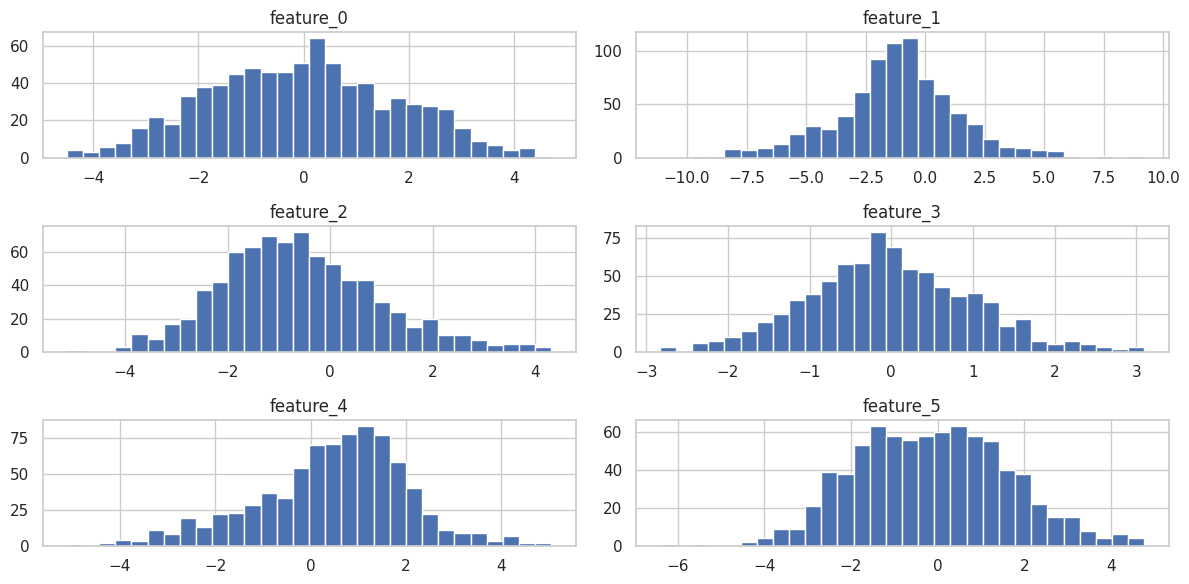

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if CONFIG["target_column"] in numeric_cols:
    numeric_cols.remove(CONFIG["target_column"])

n_show = min(len(numeric_cols), 6)
if n_show > 0:
    df[numeric_cols[:n_show]].hist(figsize=(12, 6), bins=30)
    plt.tight_layout()
    plt.show()


## 4. Split into train / validation / test

Chapter 1 recommends a conventional split of roughly 60% training,
20% validation, and 20% testing when you have enough data, and stresses that
the test set must stay untouched until final evaluation to give an honest
estimate of generalization.


In [7]:
y = df[CONFIG["target_column"]]
X = df.drop(columns=[CONFIG["target_column"]])

stratify = y if CONFIG["task_type"] == "classification" else None

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=CONFIG["test_size"], random_state=CONFIG["random_state"],
    stratify=stratify
)

stratify2 = y_train_full if CONFIG["task_type"] == "classification" else None
val_fraction_of_remainder = CONFIG["val_size"] / (1 - CONFIG["test_size"])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=val_fraction_of_remainder,
    random_state=CONFIG["random_state"], stratify=stratify2
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train: (480, 10), Validation: (160, 10), Test: (160, 10)


## 5. Preprocessing pipeline (Chapter 1: missing values, encoding, scaling)

This builds a `ColumnTransformer` that:
- **Imputes** missing values (median for numeric, most-frequent for categorical)
- **One-hot encodes** categorical/label-type features (avoids the false
  ordering problem of plain label encoding)
- **Standardizes** numeric features (mean 0, variance 1)

Fit the pipeline only on the training data, then reuse it to transform the
validation and test sets — never fit on data the model will later be judged on.


In [8]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']
Categorical features: []


## 6. Optional feature engineering (Chapter 1: polynomial transformation, binning)

- **Polynomial/interaction features**: captures relationships like `a * b`
  between two numeric features. Turn on with `CONFIG["use_polynomial_features"]`.
  Remember Occam's razor — only add these if they measurably help on the
  validation set, since they increase the risk of overfitting.
- **Binning**: turns a continuous variable into categories (e.g. age groups).
  Configure with `CONFIG["bins"]`.


In [9]:
def add_polynomial_features(X_df, degree=2):
    num_cols = X_df.select_dtypes(include=[np.number]).columns
    poly = PolynomialFeatures(degree=degree, include_bias=False, interaction_only=True)
    poly_arr = poly.fit_transform(X_df[num_cols])
    poly_cols = poly.get_feature_names_out(num_cols)
    poly_df = pd.DataFrame(poly_arr, columns=poly_cols, index=X_df.index)
    return poly_df

def apply_manual_bins(X_df, bins_config):
    X_df = X_df.copy()
    for col, edges in bins_config.items():
        if col in X_df.columns:
            X_df[f"{col}_bin"] = pd.cut(X_df[col], bins=edges, include_lowest=True)
            X_df[f"{col}_bin"] = X_df[f"{col}_bin"].astype(str)
    return X_df

if CONFIG["bins"]:
    X_train = apply_manual_bins(X_train, CONFIG["bins"])
    X_val = apply_manual_bins(X_val, CONFIG["bins"])
    X_test = apply_manual_bins(X_test, CONFIG["bins"])

if CONFIG["use_polynomial_features"]:
    X_train = pd.concat([X_train, add_polynomial_features(X_train, CONFIG["polynomial_degree"])], axis=1)
    X_val = pd.concat([X_val, add_polynomial_features(X_val, CONFIG["polynomial_degree"])], axis=1)
    X_test = pd.concat([X_test, add_polynomial_features(X_test, CONFIG["polynomial_degree"])], axis=1)
    # Recompute column lists and rebuild the preprocessor after adding columns
    categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

print("Feature engineering applied. Current shape:", X_train.shape)


Feature engineering applied. Current shape: (480, 10)


## 7. Baseline model + bias/variance diagnostics

Train a simple baseline first (Occam's razor). Then compare training vs.
validation performance to check for **overfitting** (train >> validation)
or **underfitting** (both low). This mirrors Chapter 1's discussion of the
bias-variance trade-off.


In [10]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

if CONFIG["task_type"] == "classification":
    baseline_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=CONFIG["random_state"])),
    ])
else:
    baseline_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(random_state=CONFIG["random_state"])),
    ])

baseline_model.fit(X_train, y_train)

def evaluate(model, X, y, task_type, label=""):
    preds = model.predict(X)
    if task_type == "classification":
        acc = accuracy_score(y, preds)
        f1 = f1_score(y, preds, average="weighted")
        print(f"{label} — accuracy: {acc:.3f}, weighted F1: {f1:.3f}")
        return acc
    else:
        mse = mean_squared_error(y, preds)
        r2 = r2_score(y, preds)
        print(f"{label} — MSE: {mse:.3f}, R^2: {r2:.3f}")
        return r2

train_score = evaluate(baseline_model, X_train, y_train, CONFIG["task_type"], "Training")
val_score = evaluate(baseline_model, X_val, y_val, CONFIG["task_type"], "Validation")

gap = train_score - val_score
print(f"\nTrain-validation gap: {gap:.3f}")
if gap > 0.15:
    print("Warning: large gap suggests possible OVERFITTING (high variance).")
elif train_score < 0.6:
    print("Warning: low training score suggests possible UNDERFITTING (high bias).")
else:
    print("Gap looks reasonable — no strong overfitting/underfitting signal.")


Training — accuracy: 0.771, weighted F1: 0.771
Validation — accuracy: 0.812, weighted F1: 0.812

Train-validation gap: -0.042
Gap looks reasonable — no strong overfitting/underfitting signal.


## 8. Cross-validation (Chapter 1: k-fold cross-validation)

Cross-validation gives a more reliable estimate of how the model will
generalize than a single train/validation split, and is used here to
compare candidate models and, later, to tune hyperparameters with
`GridSearchCV`.


In [11]:
cv_strategy = (
    StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=CONFIG["random_state"])
    if CONFIG["task_type"] == "classification"
    else KFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=CONFIG["random_state"])
)

scoring = "accuracy" if CONFIG["task_type"] == "classification" else "r2"

cv_scores = cross_val_score(baseline_model, X_train_full, y_train_full, cv=cv_strategy, scoring=scoring)
print(f"{CONFIG['cv_folds']}-fold CV {scoring} scores:", np.round(cv_scores, 3))
print(f"Mean: {cv_scores.mean():.3f}  Std: {cv_scores.std():.3f}")


5-fold CV accuracy scores: [0.82  0.805 0.711 0.82  0.742]
Mean: 0.780  Std: 0.045


## 9. Hyperparameter tuning with GridSearchCV + regularization

Regularization (Chapter 1: "Avoiding overfitting with regularization")
penalizes model complexity. Here we search over a regularization strength
grid, evaluated with cross-validation, to find a well-fitting model rather
than the most complex one.


In [12]:
if CONFIG["task_type"] == "classification":
    param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}
else:
    param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    baseline_model, param_grid, cv=cv_strategy, scoring=scoring, n_jobs=-1
)
grid_search.fit(X_train_full, y_train_full)

print("Best params:", grid_search.best_params_)
print("Best CV score:", round(grid_search.best_score_, 3))

best_model = grid_search.best_estimator_


Best params: {'model__C': 1}
Best CV score: 0.78


## 10. Combining models (Chapter 1: voting, bagging, boosting, stacking)

Optionally combine several models to reduce variance (bagging), reduce
bias (boosting), or blend diverse models (voting/stacking). This section
is optional — only use it if it measurably improves validation performance
over the single tuned model above.


In [13]:
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    VotingClassifier, VotingRegressor
)

if CONFIG["task_type"] == "classification":
    bagging_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=CONFIG["random_state"])),
    ])
    boosting_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=CONFIG["random_state"])),
    ])
else:
    bagging_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=CONFIG["random_state"])),
    ])
    boosting_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=CONFIG["random_state"])),
    ])

for name, model in [("Tuned baseline", best_model), ("Bagging (Random Forest)", bagging_model), ("Boosting (Gradient Boosting)", boosting_model)]:
    model.fit(X_train, y_train)
    evaluate(model, X_val, y_val, CONFIG["task_type"], name)


Tuned baseline — accuracy: 0.812, weighted F1: 0.812


Bagging (Random Forest) — accuracy: 0.887, weighted F1: 0.887
Boosting (Gradient Boosting) — accuracy: 0.881, weighted F1: 0.881


## 11. Final evaluation on the held-out test set

Only run this cell once you have finished model selection above. The test
set should be touched exactly once, to report an honest, final estimate of
generalization performance — this is the exam, not another mock exam.


=== FINAL TEST SET RESULTS ===
Test — accuracy: 0.812, weighted F1: 0.812

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        80
           1       0.85      0.76      0.80        80

    accuracy                           0.81       160
   macro avg       0.82      0.81      0.81       160
weighted avg       0.82      0.81      0.81       160



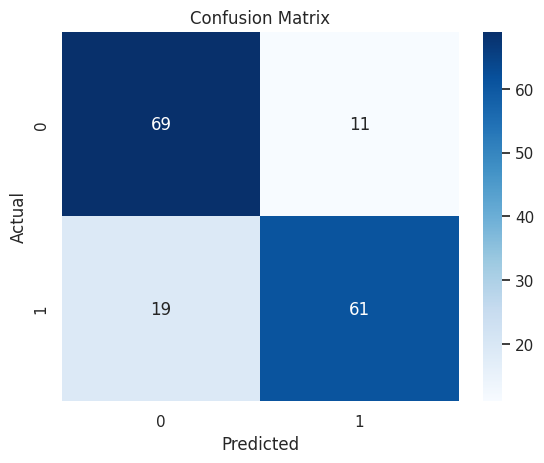

In [14]:
# Choose the model you selected in section 10 and refit on train+val before the final test
final_model = best_model  # <- replace with bagging_model / boosting_model if that performed better
final_model.fit(X_train_full, y_train_full)

print("=== FINAL TEST SET RESULTS ===")
evaluate(final_model, X_test, y_test, CONFIG["task_type"], "Test")

if CONFIG["task_type"] == "classification":
    preds = final_model.predict(X_test)
    print()
    print(classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


## 12. Learning curve (extra overfitting/underfitting diagnostic)

Plots training vs. validation score as training set size grows. A large,
persistent gap points to overfitting (high variance); both curves plateauing
at a low score points to underfitting (high bias) — see Chapter 1's
bias-variance discussion.


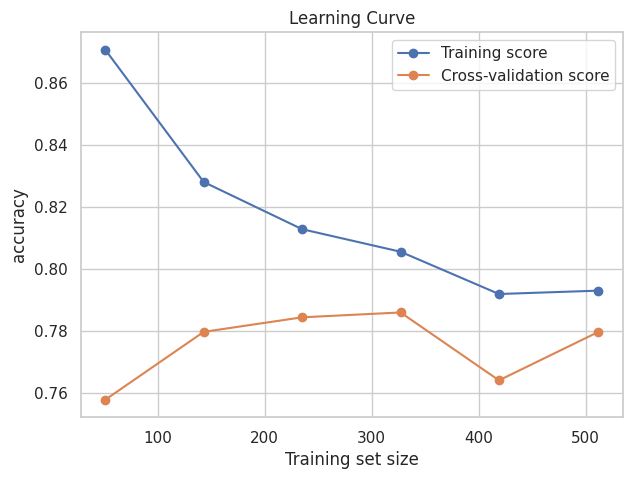

In [15]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train_full, y_train_full, cv=cv_strategy, scoring=scoring,
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-validation score")
plt.xlabel("Training set size")
plt.ylabel(scoring)
plt.title("Learning Curve")
plt.legend()
plt.show()


## Summary

Fill in your own notes here once the pipeline runs on real data:

- Dataset used:
- Task type:
- Best model and hyperparameters:
- Final test performance:
- Key preprocessing / feature engineering decisions:
- Signs of overfitting/underfitting observed, and how they were addressed:
